In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

depi_r_2_competition_1_path = kagglehub.competition_download('depi-r-2-competition-1')

print('Data source import complete.')


Data source import complete.


In [3]:
!pip install catboost gensim

In [4]:
!pip install --upgrade --force-reinstall numpy gensim

  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached smart_open-7.1.0-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-1.17.2-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.7 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
Using cached smart_open-7.1.0-py3-none-any.whl (61 kB)
Using cached wrapt-1.17.2-cp311-cp

In [5]:
#Necessary Libraries
import numpy as np
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')

#Preprocessing
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [6]:
df = pd.read_csv('depi_r_2_competition_1.csv')
df.head()


,ID,text,label
0,0,Americans Aren't Sure If Flight 370 Vanished T...,1
1,1,Pope Leo X offering indulgences to sinners sho...,0
2,2,News: 5 Uplifting Hypotheticals Of What Could ...,0
3,3,George W. Bush and Jeb Bush at a campaign stop...,0
4,4,The WADA requesting their fair share from Lanc...,0


In [7]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
def preprocess_text(text):
    #Convert text to lowercase
    text = text.lower()
    #Remove Special Characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    #Tokenize
    tokens = word_tokenize(text)
    #Remove Stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)

In [9]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'])

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, df['label'], test_size=0.2, random_state=3)

In [11]:
models = {
    'Logistic Regression': LogisticRegression(),
}
 #'Random Forest': RandomForestClassifier(),
  #  'Gradient Boosting': GradientBoostingClassifier(),
   # 'SVM': SVC(),
    #'Multinomial NB': MultinomialNB(),
    #'XGBoost': XGBClassifier(),
    #'LightGBM': LGBMClassifier(),
    #'CatBoost': CatBoostClassifier()

In [12]:
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f"\n--- {name} Results ---")
    print(f"Accuracy: {accuracy}")
    print("Classification Report:")
    print(report)


--- Logistic Regression Results ---
Accuracy: 0.7680208333333334
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      5179
           1       0.75      0.75      0.75      4377
           2       0.00      0.00      0.00        44

    accuracy                           0.77      9600
   macro avg       0.51      0.51      0.51      9600
weighted avg       0.76      0.77      0.77      9600



In [14]:
test_df = pd.read_csv('x_test.csv')
test_df['processed_text'] = test_df['text'].apply(preprocess_text)

X_test_tfidf = tfidf_vectorizer.transform(test_df['processed_text'])

In [15]:
for name, model in models.items():
    model.fit(X_tfidf, df['label'])
    y_pred = model.predict(X_test_tfidf)

    submission = pd.DataFrame({
        'ID': test_df['ID'],
        'label': y_pred.ravel()
    })

    submission.to_csv(name[:5]+'_submission.csv', index=False)

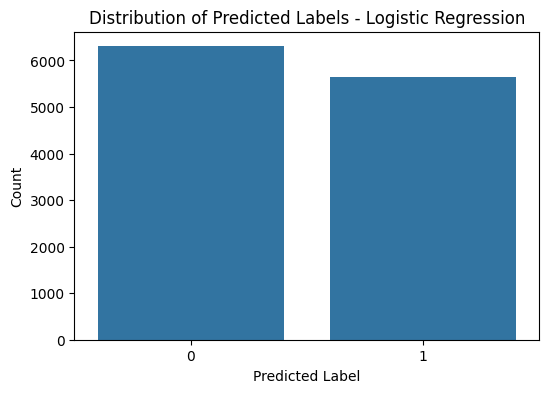

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# ... (previous code) ...

for name, model in models.items():
    # ... (training and prediction code) ...

    # Plot distribution of predicted labels
    plt.figure(figsize=(6, 4))
    sns.countplot(x=y_pred)
    plt.title(f"Distribution of Predicted Labels - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Count")
    plt.show()

    # ... (submission code) ...